# Boosting Techniques - Assignment
#### Assignment Code: DA-AG-015

1. What is Boosting in Machine Learning? Explain how it improves weak 
learners.
  - Boosting is an ensemble machine learning technique where multiple weak learners are combined to create a strong predictive model.
  - A weak learner is a model that performs only slightly better than random guessing. Boosting improves performance by training models sequentially. Each new model focuses on correcting the mistakes made by the previous models.
  - In boosting:
  - The first model is trained on the dataset.
  - The next model gives more importance to the data points that were misclassified earlier.
  - This process continues until the model performance improves.
  - By combining many weak models, boosting creates a stronger and more accurate model.
       - Example: Algorithms like AdaBoost, Gradient Boosting, XGBoost, and CatBoost use boosting techniques.
   
2.  What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?
  - AdaBoost and Gradient Boosting are both boosting algorithms used to make machine learning models more accurate.
  - AdaBoost improves the model by giving more importance to the data points that were predicted incorrectly in the previous step.
  - This means the next model tries to focus more on the mistakes made by the earlier model.
  - Gradient Boosting works differently. Instead of changing data weights, it learns from the errors (residuals) of the previous model.
  - In Gradient Boosting, each new model tries to reduce the prediction error step by step.

3. How does regularization help in XGBoost?
  - Regularization in XGBoost helps to prevent overfitting.
  - Overfitting happens when a model learns the training data too well but performs poorly on new data.
  - XGBoost uses two types of regularization:
     - L1 Regularization (Lasso) - Reduces the number of features used in the model.
     - L2 Regularization (Ridge) - Reduces the complexity of the model.
  - Benefits of regularization in XGBoost:
     - Controls model complexity
     - Prevents overfitting
     - Improves generalization
     - Makes the model more stable
     - Because of regularization, XGBoost performs very well on many real-world datasets.

4. Why is CatBoost considered efficient for handling categorical data?
  - CatBoost is designed specifically to handle categorical variables efficiently.
  - Normally, categorical data must be converted into numbers using techniques like:
     - One-Hot Encoding
     - Label Encoding
  - Advantages of CatBoost:
     - Automatically handles categorical features
     - Reduces preprocessing work
     - Prevents overfitting using ordered boosting
     - Faster training on categorical datasets

5. What are some real-world applications where boosting techniques are preferred over bagging methods?
  - Boosting techniques are preferred when high prediction accuracy is required.
  - Some real-world applications include:
     - Fraud detection - Detect fraudulent transactions in banks.
     - Credit risk prediction - Predict whether a customer will default on a loan.
     - Customer churn prediction - Identify customers who may leave a service.
     - Medical diagnosis - Detect diseases like cancer.
     - Recommendation systems - Improve product recommendations.
  - Boosting works better than bagging in these cases because it focuses on correcting mistakes and improving difficult predictions.

In [1]:
# 6. Write a Python program to: 
# Train an AdaBoost Classifier on the Breast Cancer dataset.
# Print the model accuracy.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train AdaBoost
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [2]:
# 7. Write a Python program to: 
# Train a Gradient Boosting Regressor on the California Housing dataset. 
# Evaluate performance using R-squared score.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# R2 Score
score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.7756923945143868


In [3]:
# Write a Python program to: 
# Train an XGBoost Classifier on the Breast Cancer dataset.
# Tune the learning rate using GridSearchCV.
# Print the best parameters and accuracy.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = XGBClassifier()

# GridSearch
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(model, param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'learning_rate': 0.1}
Accuracy: 0.956140350877193


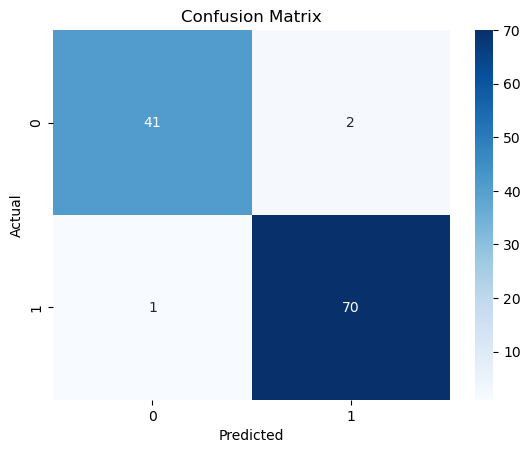

In [4]:
# 9.  Write a Python program to: 
# Train a CatBoost Classifier. 
# Plot the confusion matrix using seaborn.

from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train CatBoost model
model = CatBoostClassifier(iterations=100, learning_rate=0.1, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot using seaborn
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

10. You're working for a FinTech company trying to predict loan default using 
customer demographics and transaction behavior. 
The dataset is imbalanced, contains missing values, and has both numeric and 
categorical features. 
Describe your step-by-step data science pipeline using boosting techniques: 
  - a. Data preprocessing & handling missing/categorical values 
  - b. Choice between AdaBoost, XGBoost, or CatBoost 
  - c. Hyperparameter tuning strategy 
  - d. Evaluation metrics you'd choose and why 
  - e. How the business would benefit from your model?

     - Data Preprocessing - First, I would clean the dataset. If there are missing values in numerical columns, I would fill them using mean or median. For categorical columns, I would replace missing values with the most common value. Categorical features like gender, job type, or account type need to be converted into numbers using encoding. Since the dataset is imbalanced (few people default on loans), techniques like SMOTE or class weights can be used to balance the data.
     - Choice of Model - For this problem, boosting algorithms like XGBoost or CatBoost are good choices. These models work well with complex datasets and usually give high accuracy. If the dataset has many categorical features, CatBoost is a good option because it can handle categorical data easily.
     -  Hyperparameter Tuning - To improve the model, I would tune some important parameters such as learning rate, number of trees (n_estimators), and max depth. This can be done using GridSearchCV or RandomizedSearchCV to find the best combination of parameters.
     - Evaluation Metrics - Since the dataset is imbalanced, accuracy alone is not enough. I would use Precision, Recall, F1 Score, and ROC-AUC score to evaluate the model. Recall is especially important because it helps identify customers who are likely to default.
     - Business Benefits - This model will help the company identify customers who have a high risk of loan default. This can help the company make better loan approval decisions and reduce financial losses. It will also improve risk management and help the company make smarter financial decisions.